---
## Imports

In [7]:
from config import *
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm
import warnings, json
warnings.filterwarnings("ignore")
import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.transforms as transforms
from torchvision import models
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score, ConfusionMatrixDisplay
plt.rcParams.update({"figure.dpi":150,"axes.spines.top":False,"axes.spines.right":False,"axes.grid":True,"grid.alpha":0.3})
print("Imports ready ok")

Imports ready ok


---
## Load and Split Dataset

In [8]:
df = pd.read_csv(META_PATH)

def find_path(image_id):
    for folder in [IMG_DIR_1, IMG_DIR_2]:
        p = folder / (image_id + ".jpg")
        if p.exists(): return str(p)
    return None

df["path"]  = df["image_id"].apply(find_path)
df["label"] = df["dx"].map(CLASS_TO_IDX)
df = df.dropna(subset=["path"]).reset_index(drop=True)

train_df, val_df = train_test_split(
    df, test_size=0.20, stratify=df["label"], random_state=SEED
)
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)

print(f"Train: {len(train_df):,}  Val: {len(val_df):,}")
print(f"Class distribution (train):")
print(train_df["dx"].value_counts().to_string())

Train: 2,258  Val: 565
Class distribution (train):
dx
nv       1545
bkl       258
mel       196
bcc       114
akiec      86
vasc       33
df         26


---
## Dataset, Transforms and Sampler

In [9]:
class SkinLesionDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        image = Image.open(str(row["path"])).convert("RGB")
        label = int(row["label"])
        if self.transform: image = self.transform(image)
        return image, label

transform_baseline = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

transform_augmented = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

transform_val = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

def make_weighted_sampler(dataframe):
    # Each sample gets weight = 1 / count(its class)
    # Rare classes sampled more frequently -> balanced batches
    label_arr     = dataframe["label"].values
    class_counts  = np.bincount(label_arr, minlength=NUM_CLASSES).astype(float)
    class_weights = 1.0 / np.where(class_counts > 0, class_counts, 1.0)
    sample_weights = class_weights[label_arr]
    return WeightedRandomSampler(torch.FloatTensor(sample_weights), len(sample_weights), replacement=True)

def compute_class_weights(dataframe):
    counts  = np.bincount(dataframe["label"].values, minlength=NUM_CLASSES).astype(float)
    weights = 1.0 / np.where(counts > 0, counts, 1.0)
    weights = weights / weights.sum() * NUM_CLASSES
    return torch.tensor(weights, dtype=torch.float32).to(DEVICE)

print("Dataset class and transforms defined ok")

Dataset class and transforms defined ok


---
## ResNet-18 Model

In [10]:
def build_resnet18(num_classes=NUM_CLASSES, freeze_body=True):
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    if freeze_body:
        for p in model.parameters(): p.requires_grad = False
    in_f = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(p=DROPOUT_RATE),
        nn.Linear(in_f, 256),
        nn.ReLU(inplace=True),
        nn.Linear(256, num_classes)
    )
    return model

_m = build_resnet18(freeze_body=True)
total     = sum(p.numel() for p in _m.parameters())
trainable = sum(p.numel() for p in _m.parameters() if p.requires_grad)
print(f"Total params:     {total:,}")
print(f"Trainable (P1):   {trainable:,}  ({100*trainable/total:.1f}%)")
print(f"Frozen (P1):      {total-trainable:,}")
del _m

Total params:     11,309,639
Trainable (P1):   133,127  (1.2%)
Frozen (P1):      11,176,512


---
## Training Functions

In [11]:
def train_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss = correct = total = 0
    for imgs, labels in tqdm(loader, desc="  Train", leave=False):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        logits = model(imgs)
        loss   = criterion(logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        correct    += (logits.argmax(1) == labels).sum().item()
        total      += imgs.size(0)
    return total_loss/total, correct/total

@torch.no_grad()
def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss = correct = total = 0
    all_preds = []; all_labels = []
    for imgs, labels in tqdm(loader, desc="  Val", leave=False):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        logits = model(imgs)
        loss   = criterion(logits, labels)
        total_loss += loss.item() * imgs.size(0)
        preds       = logits.argmax(1)
        correct    += (preds == labels).sum().item()
        total      += imgs.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    return total_loss/total, correct/total, all_preds, all_labels

def train_model(model, tr_loader, vl_loader, n_epochs, lr, cw, tag):
    model     = model.to(DEVICE)
    criterion = nn.CrossEntropyLoss(weight=cw)
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()),
                           lr=lr, weight_decay=WEIGHT_DECAY)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)
    history   = {k:[] for k in ["train_loss","val_loss","train_acc","val_acc"]}
    best      = float("inf")
    save_path = MODELS_DIR / f"best_{tag}.pth"
    for ep in range(1, n_epochs+1):
        tl, ta = train_epoch(model, tr_loader, criterion, optimizer)
        vl, va, _, _ = eval_epoch(model, vl_loader, criterion)
        scheduler.step(vl)
        for k, v in zip(["train_loss","val_loss","train_acc","val_acc"],[tl,vl,ta,va]):
            history[k].append(v)
        if vl < best:
            best = vl; torch.save(model.state_dict(), save_path)
        print(f"  Ep {ep:02d}/{n_epochs}  loss {tl:.4f}->{vl:.4f}  acc {ta:.3f}->{va:.3f}")
    model.load_state_dict(torch.load(save_path, map_location=DEVICE))
    print(f"  Best checkpoint loaded (val_loss={best:.4f}) ok")
    return model, history

def plot_curves(histories, labels, title, fname):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    fig.suptitle(title, fontsize=14, fontweight="bold")
    colors = ["#3498db","#e74c3c","#2ecc71"]
    for h, lbl, col in zip(histories, labels, colors):
        ep = range(1, len(h["train_loss"])+1)
        axes[0].plot(ep, h["train_loss"], "--", color=col, alpha=0.5, label=f"{lbl} train")
        axes[0].plot(ep, h["val_loss"],   "-",  color=col, label=f"{lbl} val")
        axes[1].plot(ep, h["train_acc"],  "--", color=col, alpha=0.5)
        axes[1].plot(ep, h["val_acc"],    "-",  color=col)
    for ax, ylabel in zip(axes, ["Loss","Accuracy"]):
        ax.set_xlabel("Epoch"); ax.set_ylabel(ylabel); ax.legend(fontsize=9)
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / fname, bbox_inches="tight")
    plt.show()

print("All training functions defined ok")

All training functions defined ok


---
## Experiment A -- Baseline CNN

ResNet-18 with class weighting and WeightedRandomSampler, no image augmentation.

=== EXPERIMENT A: Baseline CNN ===
-- Phase 1: Head only --


  Train:   0%|          | 0/283 [00:00<?, ?it/s]

  Val:   0%|          | 0/71 [00:00<?, ?it/s]

  Ep 01/5  loss 1.0727->1.8033  acc 0.360->0.129


  Train:   0%|          | 0/283 [00:00<?, ?it/s]

...

  Val:   0%|          | 0/71 [00:00<?, ?it/s]

  Ep 14/15  loss 0.0101->2.2565  acc 0.990->0.821


  Train:   0%|          | 0/283 [00:00<?, ?it/s]

  Val:   0%|          | 0/71 [00:00<?, ?it/s]

  Ep 15/15  loss 0.0042->2.0825  acc 0.992->0.819
  Best checkpoint loaded (val_loss=1.2531) ok


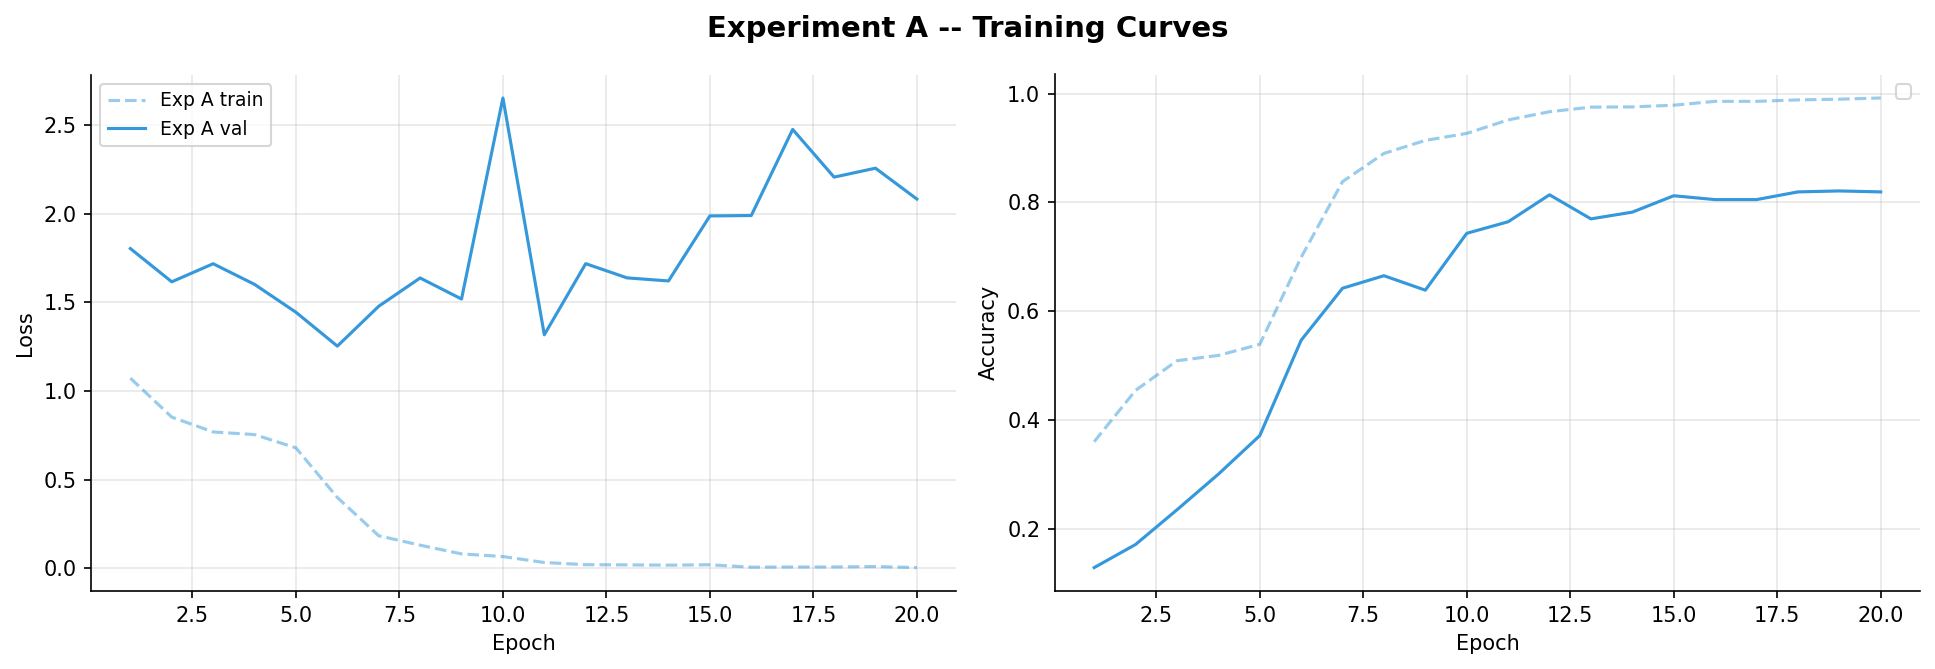

In [12]:
print("=== EXPERIMENT A: Baseline CNN ===")
cw_A  = compute_class_weights(train_df)
ds_A  = SkinLesionDataset(train_df, transform=transform_baseline)
ds_V  = SkinLesionDataset(val_df,   transform=transform_val)
ldr_A = DataLoader(ds_A, batch_size=BATCH_SIZE, sampler=make_weighted_sampler(train_df), num_workers=0)
ldr_V = DataLoader(ds_V, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

model_A = build_resnet18(freeze_body=True)
print("-- Phase 1: Head only --")
model_A, hA1 = train_model(model_A, ldr_A, ldr_V, EPOCHS_PHASE1, LR_PHASE1, cw_A, "A_p1")
print("-- Phase 2: Full fine-tuning --")
for p in model_A.parameters(): p.requires_grad = True
model_A, hA2 = train_model(model_A, ldr_A, ldr_V, EPOCHS_PHASE2, LR_PHASE2, cw_A, "A_p2")
hist_A = {k: hA1[k]+hA2[k] for k in hA1}
plot_curves([hist_A], ["Exp A"], "Experiment A -- Training Curves", "02_curves_A.png")

  Val:   0%|          | 0/71 [00:00<?, ?it/s]

Macro F1 -- Experiment A: 0.4793

              precision    recall  f1-score   support

       akiec       0.29      0.29      0.29        21
         bcc       0.50      0.62      0.55        29
         bkl       0.41      0.66      0.50        64
          df       0.26      0.71      0.38         7
         mel       0.18      0.63      0.28        49
          nv       0.98      0.52      0.68       387
        vasc       0.60      0.75      0.67         8

    accuracy                           0.55       565
   macro avg       0.46      0.60      0.48       565
weighted avg       0.78      0.55      0.60       565



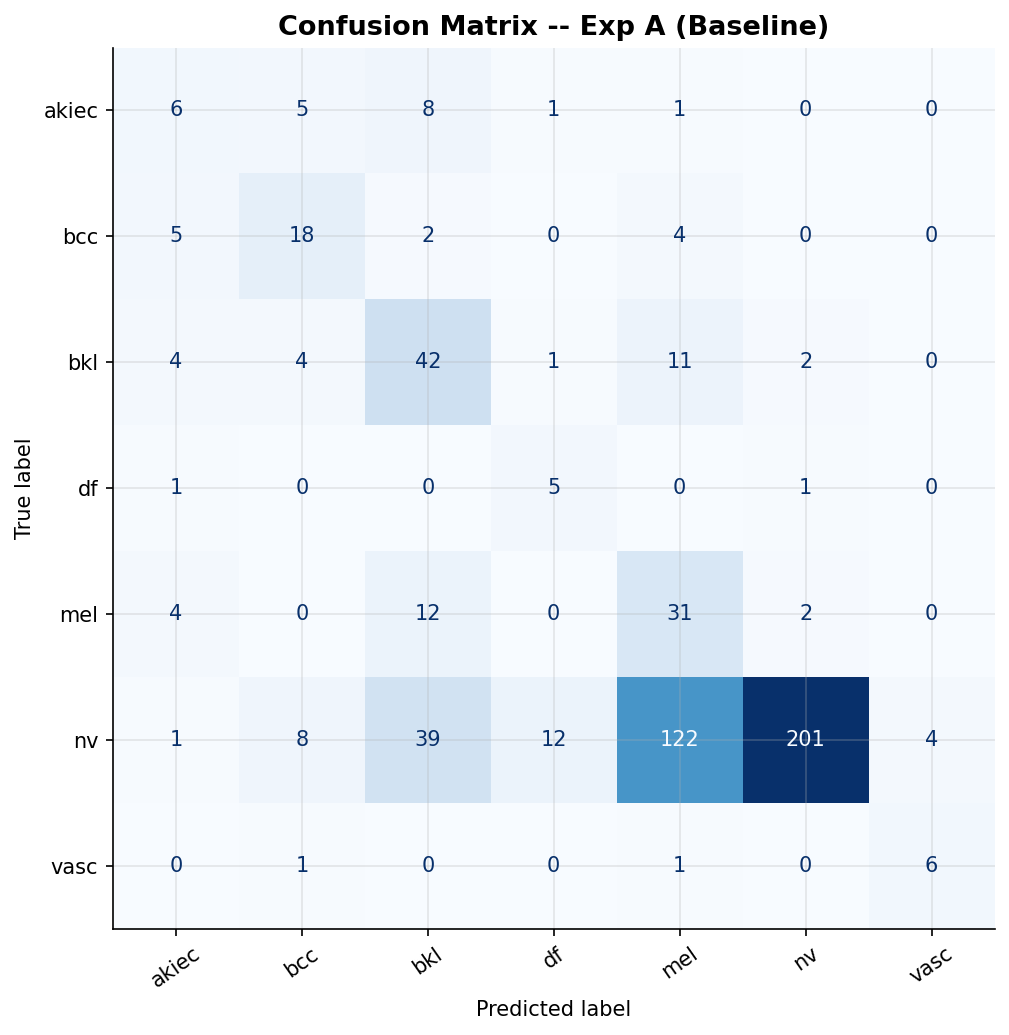

In [13]:
_, _, preds_A, labels_A = eval_epoch(model_A, ldr_V, nn.CrossEntropyLoss(weight=cw_A))
f1_A = f1_score(labels_A, preds_A, average="macro")
print(f"Macro F1 -- Experiment A: {f1_A:.4f}\n")
print(classification_report(labels_A, preds_A, target_names=CLASS_NAMES))

fig, ax = plt.subplots(figsize=(8,7))
ConfusionMatrixDisplay(confusion_matrix(labels_A,preds_A), display_labels=CLASS_NAMES).plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Confusion Matrix -- Exp A (Baseline)", fontsize=13, fontweight="bold")
plt.xticks(rotation=35); plt.tight_layout()
plt.savefig(PLOTS_DIR/"02_confusion_A.png", bbox_inches="tight"); plt.show()

---
## Experiment B -- Standard Augmentation CNN

Same as Exp A but training data uses `transform_augmented` (flips, rotation, color jitter).
This is the fair comparison baseline for Exp C.

=== EXPERIMENT B: Standard Augmentation CNN ===
-- Phase 1 --


  Train:   0%|          | 0/283 [00:00<?, ?it/s]

  Val:   0%|          | 0/71 [00:00<?, ?it/s]

  Ep 01/5  loss 1.3124->2.5149  acc 0.280->0.048


  Train:   0%|          | 0/283 [00:00<?, ?it/s]

...

  Val:   0%|          | 0/71 [00:00<?, ?it/s]

  Ep 14/15  loss 0.0827->1.3047  acc 0.879->0.664


  Train:   0%|          | 0/283 [00:00<?, ?it/s]

  Val:   0%|          | 0/71 [00:00<?, ?it/s]

  Ep 15/15  loss 0.0865->1.3769  acc 0.891->0.674
  Best checkpoint loaded (val_loss=1.1742) ok


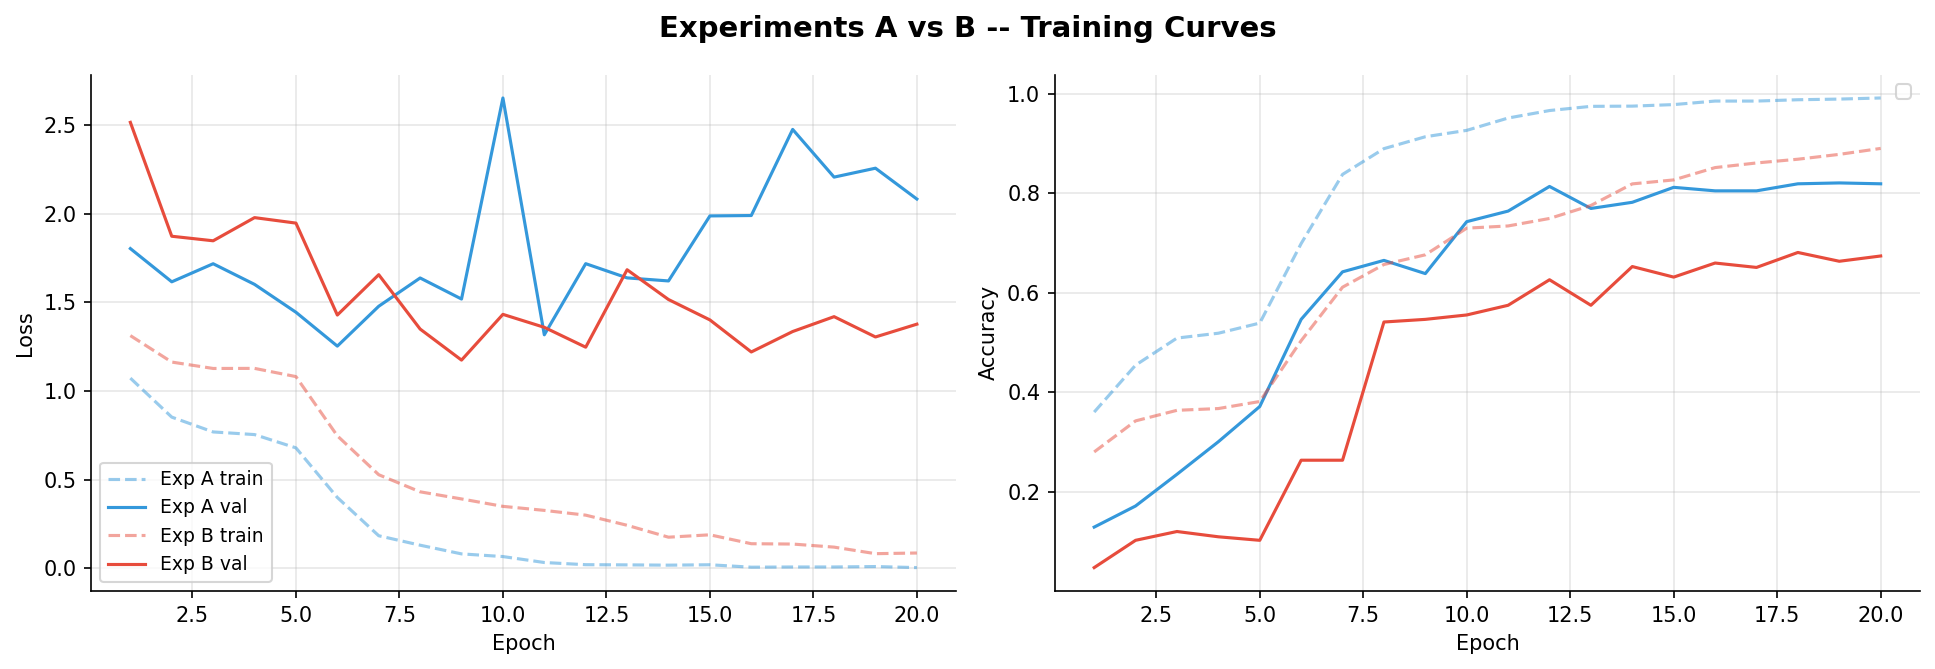

In [15]:
print("=== EXPERIMENT B: Standard Augmentation CNN ===")
ds_B  = SkinLesionDataset(train_df, transform=transform_augmented)
ldr_B = DataLoader(ds_B, batch_size=BATCH_SIZE, sampler=make_weighted_sampler(train_df), num_workers=0)

model_B = build_resnet18(freeze_body=True)
print("-- Phase 1 --")
model_B, hB1 = train_model(model_B, ldr_B, ldr_V, EPOCHS_PHASE1, LR_PHASE1, cw_A, "B_p1")
print("-- Phase 2 --")
for p in model_B.parameters(): p.requires_grad = True
model_B, hB2 = train_model(model_B, ldr_B, ldr_V, EPOCHS_PHASE2, LR_PHASE2, cw_A, "B_p2")
hist_B = {k: hB1[k]+hB2[k] for k in hB1}
plot_curves([hist_A, hist_B], ["Exp A","Exp B"], "Experiments A vs B -- Training Curves", "02_curves_AB.png")

  Val:   0%|          | 0/71 [00:00<?, ?it/s]

Macro F1 -- Experiment B: 0.4733

              precision    recall  f1-score   support

       akiec       0.24      0.57      0.34        21
         bcc       0.61      0.79      0.69        29
         bkl       0.56      0.39      0.46        64
          df       0.08      0.86      0.14         7
         mel       0.25      0.69      0.37        49
          nv       0.99      0.52      0.68       387
        vasc       0.50      0.88      0.64         8

    accuracy                           0.55       565
   macro avg       0.46      0.67      0.47       565
weighted avg       0.81      0.55      0.61       565



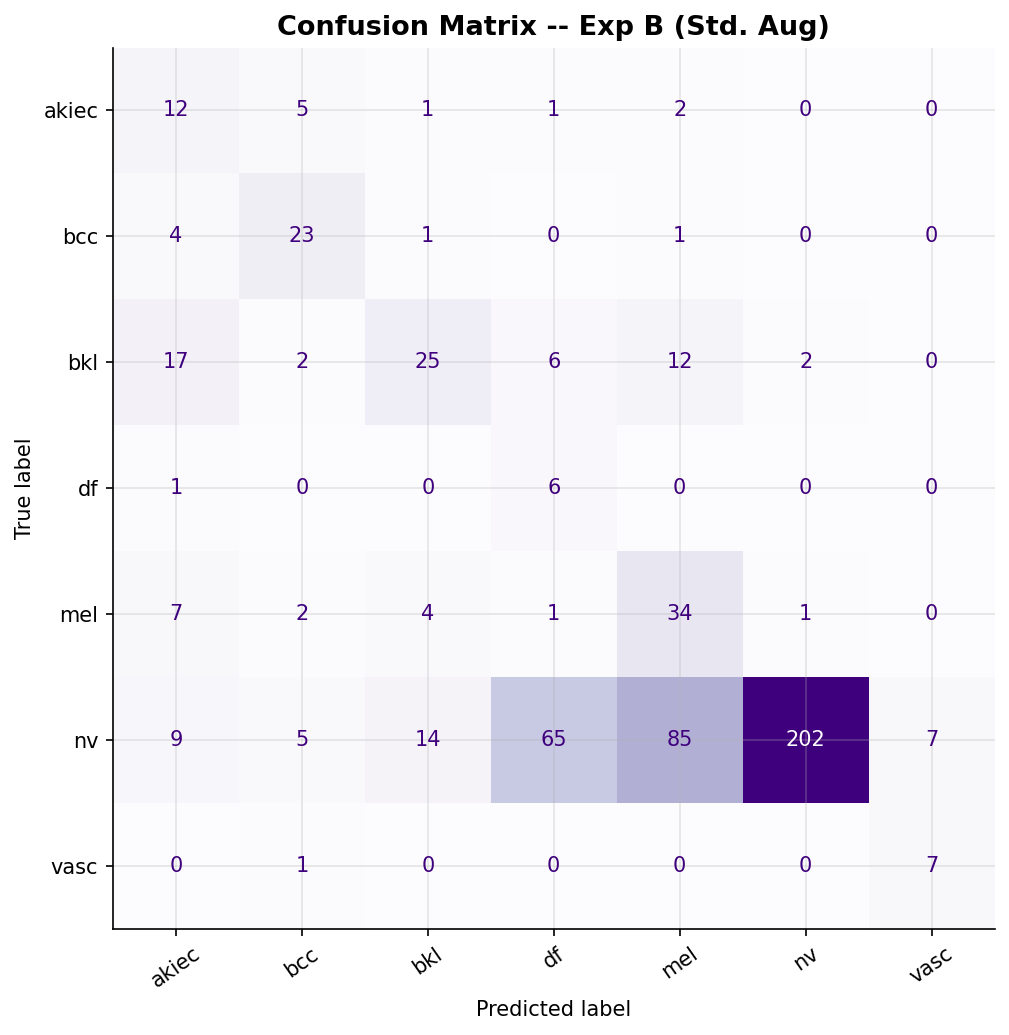

In [16]:
_, _, preds_B, labels_B = eval_epoch(model_B, ldr_V, nn.CrossEntropyLoss(weight=cw_A))
f1_B = f1_score(labels_B, preds_B, average="macro")
print(f"Macro F1 -- Experiment B: {f1_B:.4f}\n")
print(classification_report(labels_B, preds_B, target_names=CLASS_NAMES))

fig, ax = plt.subplots(figsize=(8,7))
ConfusionMatrixDisplay(confusion_matrix(labels_B,preds_B), display_labels=CLASS_NAMES).plot(ax=ax, cmap="Purples", colorbar=False)
ax.set_title("Confusion Matrix -- Exp B (Std. Aug)", fontsize=13, fontweight="bold")
plt.xticks(rotation=35); plt.tight_layout()
plt.savefig(PLOTS_DIR/"02_confusion_B.png", bbox_inches="tight"); plt.show()

---
## Save Results for Notebook 04

In [17]:
f1_A_per = f1_score(labels_A, preds_A, average=None, labels=list(range(NUM_CLASSES)))
f1_B_per = f1_score(labels_B, preds_B, average=None, labels=list(range(NUM_CLASSES)))

import pandas as pd
cmp = pd.DataFrame({"Class":CLASS_NAMES,"Exp A":f1_A_per.round(3),"Exp B":f1_B_per.round(3),"delta":(f1_B_per-f1_A_per).round(3)})
print(cmp.to_string(index=False))
print(f"\nMacro: A={f1_A:.4f}  B={f1_B:.4f}  delta={f1_B-f1_A:+.4f}")

torch.save({
    "f1_A":f1_A,"preds_A":preds_A,"labels_A":labels_A,"f1_A_per_class":f1_A_per.tolist(),
    "f1_B":f1_B,"preds_B":preds_B,"labels_B":labels_B,"f1_B_per_class":f1_B_per.tolist(),
    "val_df_index": val_df.index.tolist(),
}, "outputs/results_AB.pt")
print("\nSaved -> outputs/results_AB.pt")
print("Next -> run 03_dcgan_allclass.ipynb")

Class  Exp A  Exp B  delta
akiec  0.286  0.338  0.052
  bcc  0.554  0.687  0.133
  bkl  0.503  0.459 -0.044
   df  0.385  0.140 -0.245
  mel  0.283  0.372  0.088
   nv  0.678  0.682  0.005
 vasc  0.667  0.636 -0.030

Macro: A=0.4793  B=0.4733  delta=-0.0059

Saved -> outputs/results_AB.pt
Next -> run 03_dcgan_allclass.ipynb
